In [1]:
from keras.utils import image_dataset_from_directory
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import apply_affine_transform
from sklearn.utils.class_weight import compute_class_weight
from keras.applications.vgg16 import VGG16
from keras.applications.vgg16 import preprocess_input
from keras.applications import vgg16
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import RandomFlip
from tensorflow.keras.layers import RandomZoom
from tensorflow.keras.layers import RandomRotation
from tensorflow.keras.layers import RandomTranslation
from tensorflow.keras.layers import Rescaling,Resizing
from sklearn.metrics import classification_report,confusion_matrix
from collections import Counter
import random

import numpy as np
import matplotlib.pyplot as plt
import prettypyplot as pplt
import seaborn as sns

import cv2
import os
import shutil
from PIL import Image

In [ ]:
src_dir = './train'         
dst_dir = './train_oversampling' 

class_counts = {}
for class_name in os.listdir(src_dir):
    class_path = os.path.join(src_dir, class_name)
    if not os.path.isdir(class_path):
        continue
    images = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]
    class_counts[class_name] = len(images)

N = max(class_counts.values())
print(f"Maximum class size (N) = {N}")
print("Original class counts:", class_counts)

if os.path.exists(dst_dir):
    shutil.rmtree(dst_dir)
os.makedirs(dst_dir)

for class_name in class_counts:
    print (class_name,class_counts[class_name])
    img_no=class_counts[class_name]
    src_class_dir = os.path.join(src_dir, class_name)
    dst_class_dir = os.path.join(dst_dir, class_name)
    os.makedirs(dst_class_dir, exist_ok=True)

    images = os.listdir(src_class_dir)
    random.shuffle(images)
    selected_images = images
    for img_name in selected_images:
        src_path = os.path.join(src_class_dir, img_name)
        dst_path = os.path.join(dst_class_dir, img_name)
        shutil.copy(src_path, dst_path)
    if img_no<N:
        count=0
        for i in range(N-img_no):
            count+=1
            random_image_name = random.choice(images)
            image_path = os.path.join(src_class_dir, random_image_name)
            image = Image.open(image_path)
            original_size=image.size
            #angle = random.choice([90,180,270])
            angle = random.randint(1,359)
            rotated_image = image.rotate(angle, expand=True)
            rotated_width, rotated_height = rotated_image.size
            orig_width, orig_height = original_size

            left = (rotated_width - orig_width) // 2
            top = (rotated_height - orig_height) // 2
            right = left + orig_width
            bottom = top + orig_height

            cropped = rotated_image.crop((left, top, right, bottom))
            output_path = os.path.join(dst_class_dir, f"rotated_{angle}_{count}_{random_image_name}")
            cropped.save(output_path)
        print (f'rotated {count} images, total of {count+img_no}')

print(f"Copied {N} images per class to {dst_dir}")

Maximum class size (N) = 2663
Original class counts: {'basophil': 974, 'eosinophil': 2493, 'erythroblast': 1240, 'ig': 2316, 'lymphocyte': 971, 'monocyte': 1136, 'neutrophil': 2663, 'platelet': 1878}
basophil 974
rotated 1689 images, total of 2663
eosinophil 2493
rotated 170 images, total of 2663
erythroblast 1240
rotated 1423 images, total of 2663
ig 2316
rotated 347 images, total of 2663
lymphocyte 971
rotated 1692 images, total of 2663
monocyte 1136
rotated 1527 images, total of 2663
neutrophil 2663
platelet 1878
rotated 785 images, total of 2663
Copied 2663 images per class to ./train_oversampling


In [4]:
balanced_ds=image_dataset_from_directory('./train_oversampling',seed=42,batch_size=16,image_size=(363,360))

Found 21304 files belonging to 8 classes.


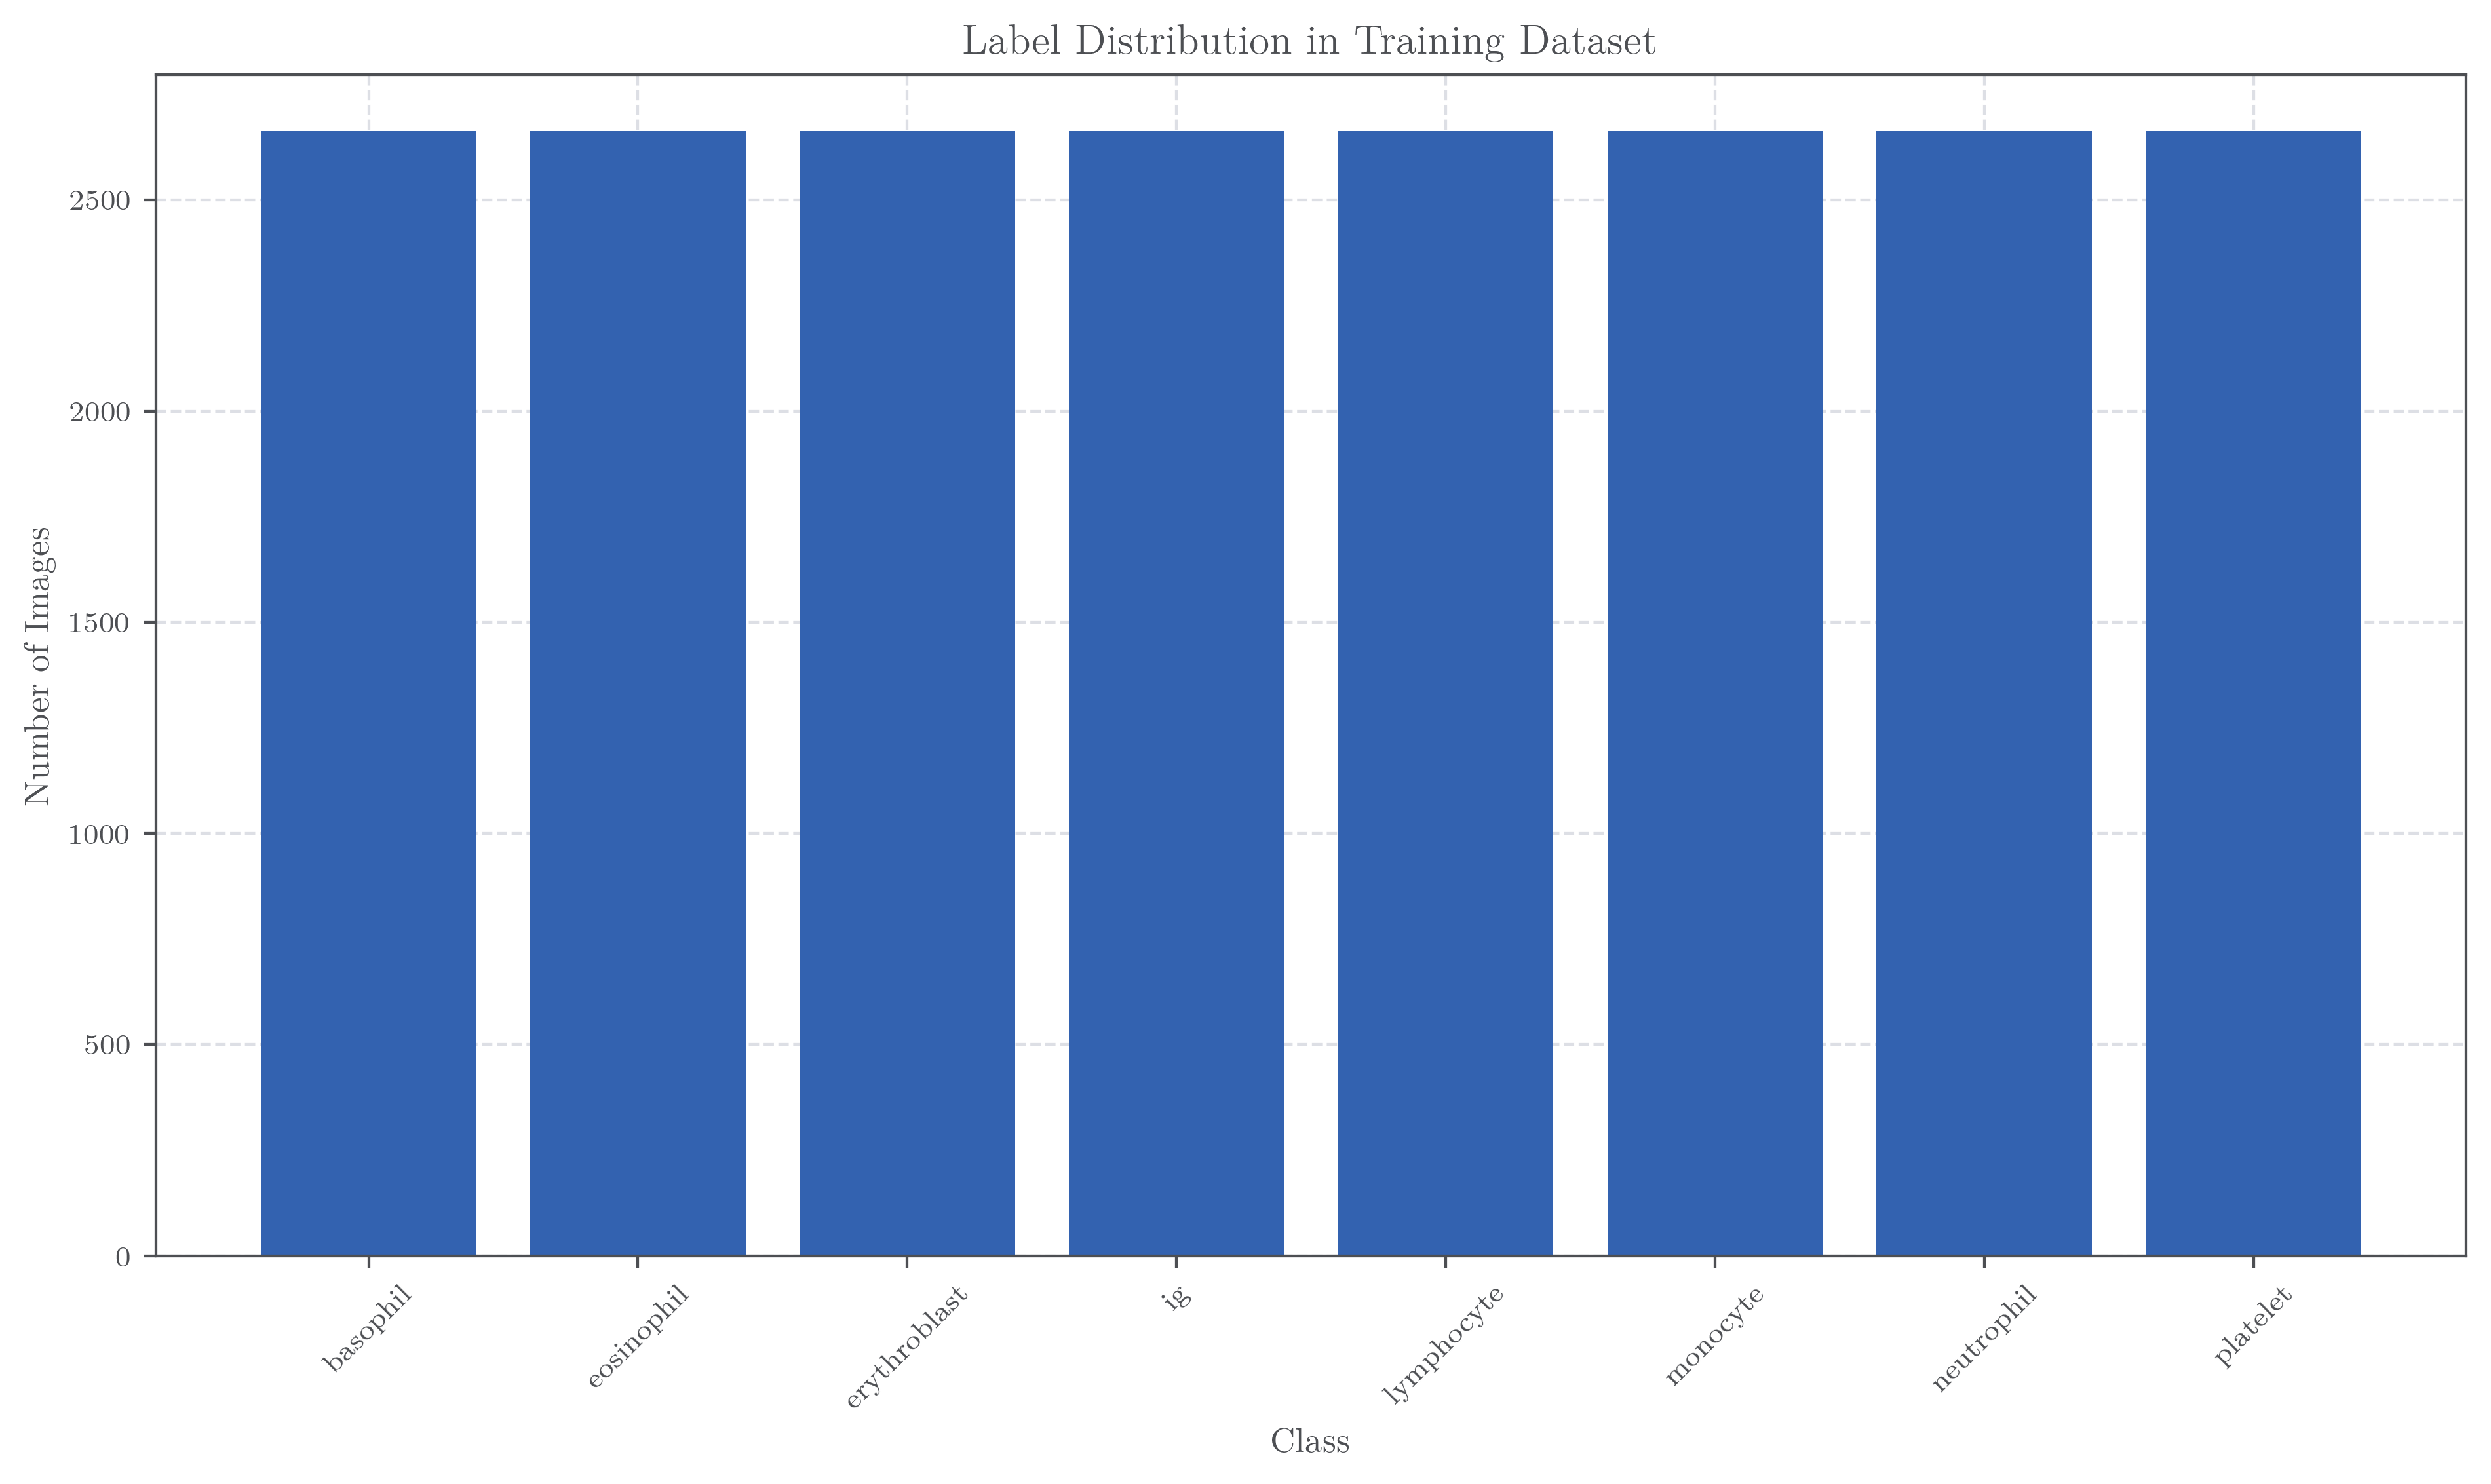

In [ ]:
pplt.use_style()
all_labels = []
for _, labels in balanced_ds:
    all_labels.extend(labels.numpy())

label_counts = Counter(all_labels)

class_names = balanced_ds.class_names
sorted_labels = sorted(label_counts.items())

labels, counts = zip(*sorted_labels)
label_names = [class_names[i] for i in labels]

plt.figure(figsize=(10, 6))
plt.bar(label_names, counts)
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.title('Label Distribution in Training Dataset')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
val_ds=image_dataset_from_directory('./val',seed=42,batch_size=16,image_size=(363,360),label_mode='int')

Found 3421 files belonging to 8 classes.


In [7]:
#preprocessing the oversampled data
train_ds=balanced_ds.map(lambda x,y:(preprocess_input(x),y))
val_ds=val_ds.map(lambda x,y:(preprocess_input(x),y))

In [8]:
base_model=VGG16(weights='imagenet',include_top=False)
base_model.trainable=False
inputs=Input(shape=(363,360,3))
x=RandomRotation(0.1)(inputs)
x=RandomTranslation(height_factor=0.1,width_factor=0.1)(x)
x=RandomZoom(0.1)(x)
x=RandomFlip('horizontal')(x)
x=Resizing(64,64)(x)
x=Rescaling(1/255)(x)

x=base_model(x)
x=GlobalAveragePooling2D()(x)
x=Dense(1024,activation='relu')(x)
x=Dropout(rate=0.2)(x)
x=Dense(512,activation='relu')(x)
x=Dropout(rate=0.2)(x)
outputs=Dense(8,activation='softmax')(x)
model=Model(inputs=inputs,outputs=outputs)

In [9]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [10]:
history_model=model.fit(train_ds,validation_data=val_ds,epochs=5)

Epoch 1/5
1332/1332 ━━━━━━━━━━━━━━━━━━━━ 317s 236ms/step - accuracy: 0.5293 - loss: 1.2384 - val_accuracy: 0.7328 - val_loss: 0.7383
Epoch 2/5
1332/1332 ━━━━━━━━━━━━━━━━━━━━ 427s 315ms/step - accuracy: 0.6912 - loss: 0.8431 - val_accuracy: 0.7132 - val_loss: 0.7582
Epoch 3/5
1332/1332 ━━━━━━━━━━━━━━━━━━━━ 323s 242ms/step - accuracy: 0.7018 - loss: 0.7984 - val_accuracy: 0.7322 - val_loss: 0.7407
Epoch 4/5
1332/1332 ━━━━━━━━━━━━━━━━━━━━ 339s 254ms/step - accuracy: 0.7139 - loss: 0.7742 - val_accuracy: 0.7662 - val_loss: 0.6462
Epoch 5/5
1332/1332 ━━━━━━━━━━━━━━━━━━━━ 306s 229ms/step - accuracy: 0.7295 - loss: 0.7342 - val_accuracy: 0.7498 - val_loss: 0.6877


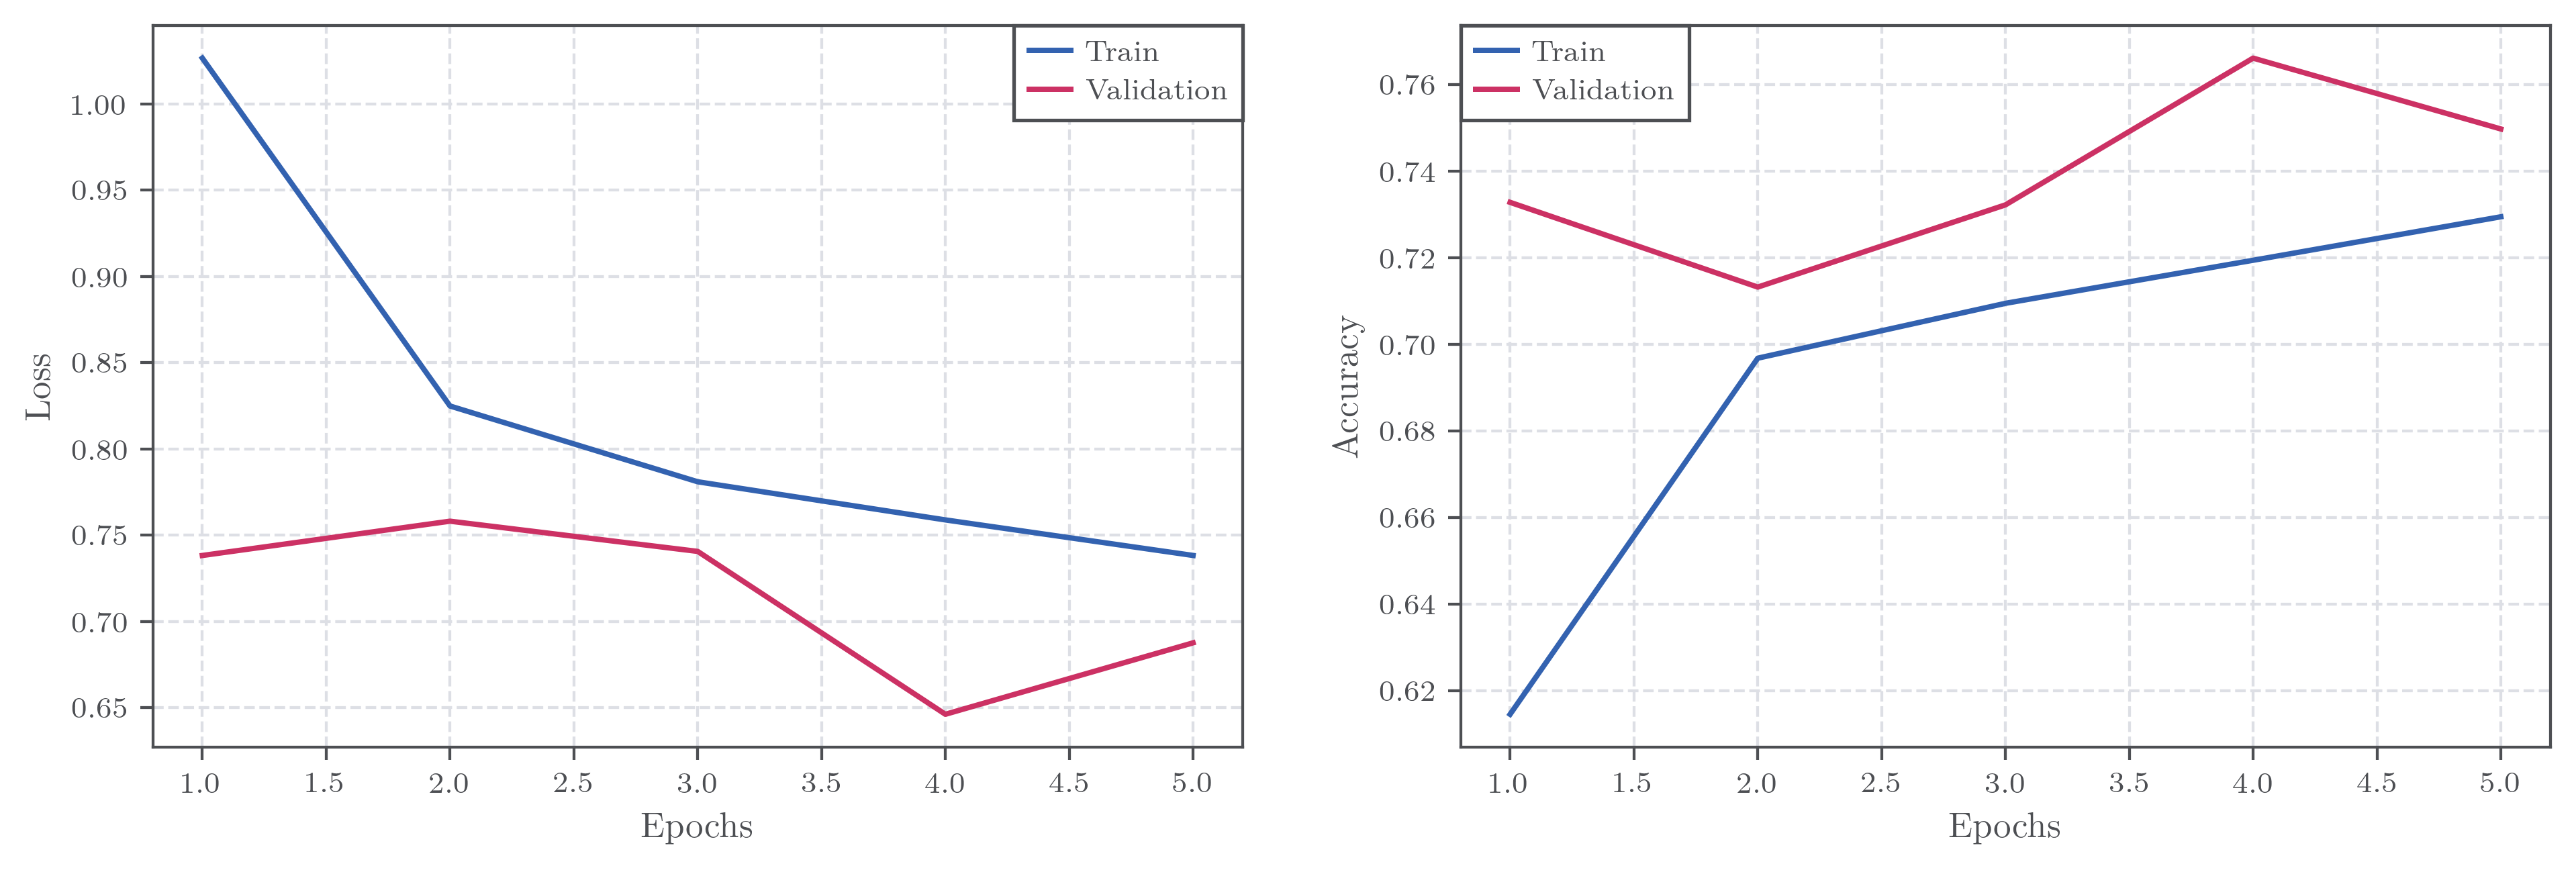

In [11]:
pplt.use_style()
loss=history_model.history['loss']
val_loss=history_model.history['val_loss']
accuracy=history_model.history['accuracy']
val_accuracy=history_model.history['val_accuracy']
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.plot(np.arange(1,6),loss,label='Train')
plt.plot(np.arange(1,6),val_loss,label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend();
plt.subplot(122)
plt.plot(np.arange(1,6),accuracy,label='Train')
plt.plot(np.arange(1,6),val_accuracy,label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend();

In [12]:
model.save("second_model_vgg16_oversampling.h5")

In [13]:
def get_predictions_and_labels(dataset):
    true_labels = []
    pred_labels = []

    for images, labels in dataset:
        
        preds = model.predict(images, verbose=0)  # Get the model's predictions
        pred_labels.extend(np.argmax(preds, axis=-1))  # Get the predicted labels (argmax)

        true_labels.extend(labels.numpy())  # Get the true labels

    return np.array(true_labels), np.array(pred_labels)

y_true, y_pred = get_predictions_and_labels(val_ds)

In [14]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

    basophil       0.47      0.79      0.59       244
  eosinophil       0.96      0.64      0.77       624
erythroblast       0.77      0.75      0.76       311
          ig       0.63      0.60      0.61       579
  lymphocyte       0.74      0.88      0.80       243
    monocyte       0.51      0.55      0.53       284
  neutrophil       0.85      0.91      0.88       666
    platelet       0.96      0.90      0.93       470

    accuracy                           0.75      3421
   macro avg       0.74      0.75      0.73      3421
weighted avg       0.78      0.75      0.75      3421



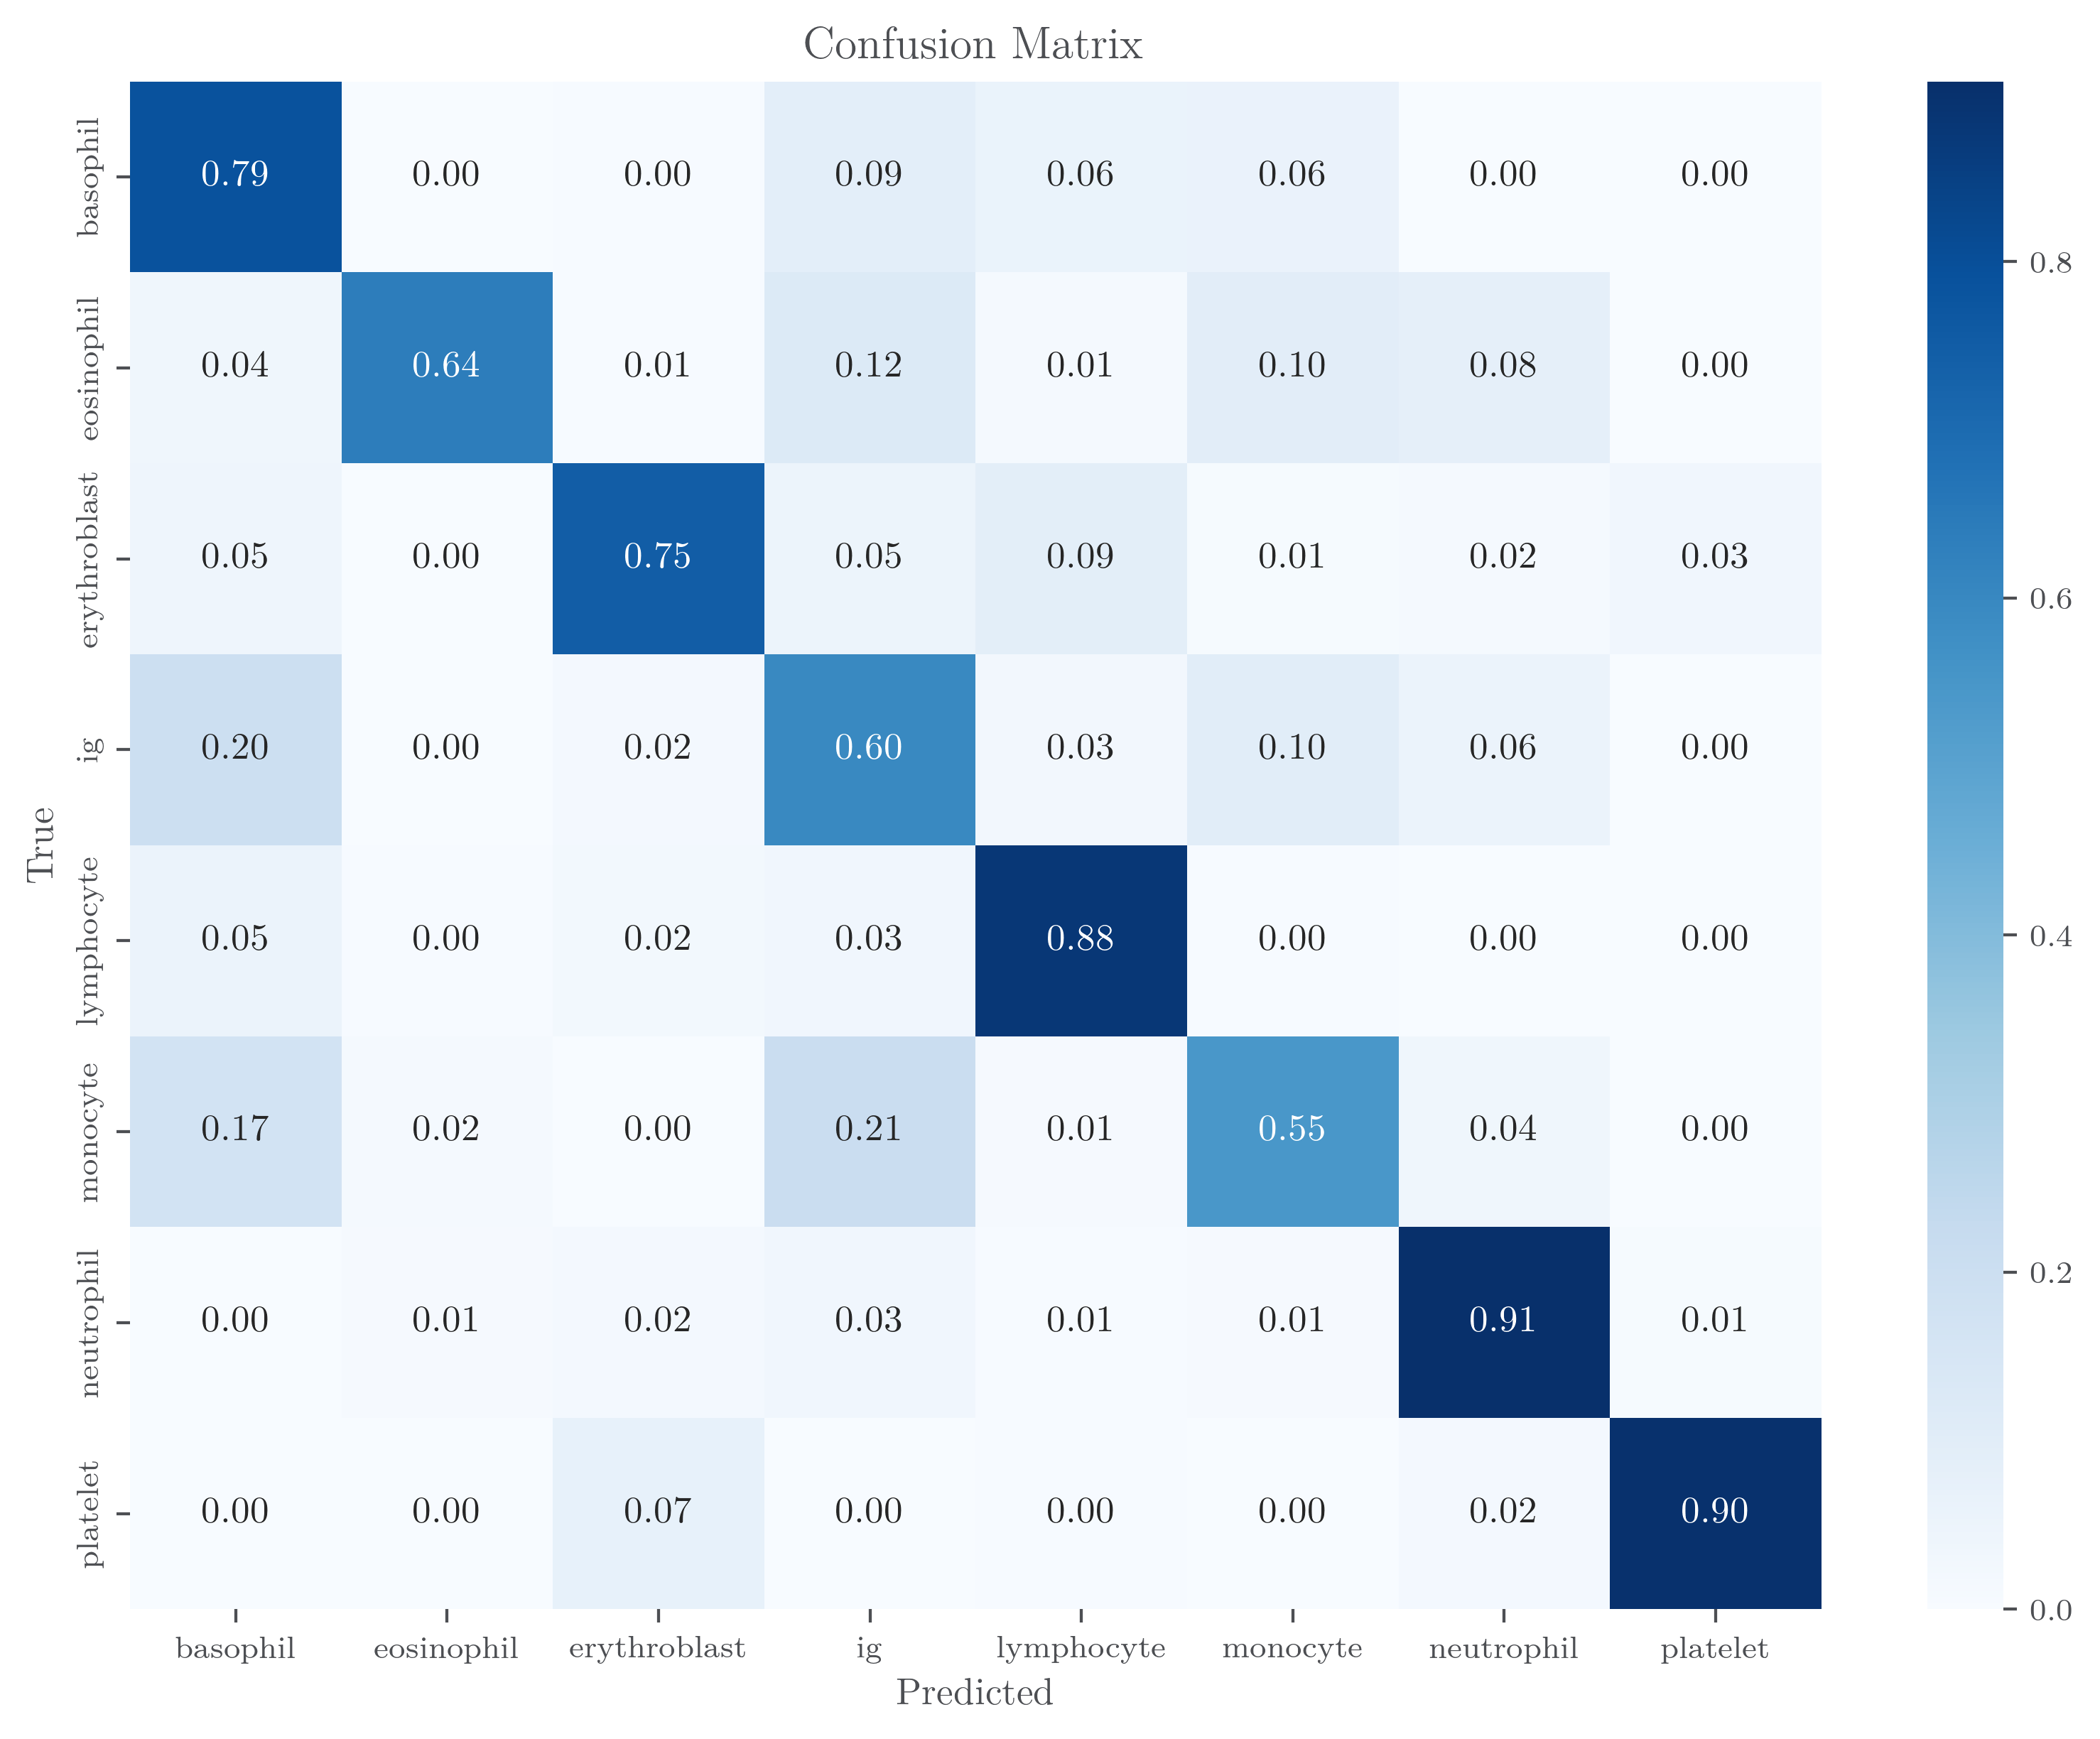

In [17]:
cm = confusion_matrix(y_true, y_pred,normalize='true')
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, xticklabels=class_names, yticklabels=class_names, fmt='.2f', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()